# Welcome to Colab!

In [6]:
import pandas as pd
url = "https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch02/pl_data.csv"
df = pd.read_csv(url)			# loads csv file into DataFrame

print("\nFirst 5 rows of DataFrame")
print(df.head( ))

print ("\nNo. of rows, columns in dataset:")
print(df.shape)

print("\nSummary of DataFrame:")
print(df.info( ))

print("\nNo. of duplicate rows:")
print(df.duplicated( ).sum( ))



First 5 rows of DataFrame
  cgpa     iq placement
0  6,8  123.0       Yes
1  5,9  106.0        No
2  5,3  121.0        No
3  7,4  132.0       Yes
4  5,8  142.0        No

No. of rows, columns in dataset:
(100, 3)

Summary of DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB
None

No. of duplicate rows:
0


In [7]:
df['cgpa'] = df['cgpa'].str.replace(',', '.')
df['cgpa'] = df['cgpa'].astype(float)
df['placement'] = df['placement'].map({'Yes':1, 'No': 0})

print(df.head( ))
print("Type of cgpa = ", df['cgpa'].dtype)
print("Type of placement = ", df['placement'].dtype)


   cgpa     iq  placement
0   6.8  123.0          1
1   5.9  106.0          0
2   5.3  121.0          0
3   7.4  132.0          1
4   5.8  142.0          0
Type of cgpa =  float64
Type of placement =  int64


In [8]:
print(df.describe( ))

            cgpa          iq   placement
count  95.000000  100.000000  100.000000
mean    5.988421  123.580000    0.500000
std     1.157112   39.944198    0.502519
min     3.300000   37.000000    0.000000
25%     5.000000  101.500000    0.000000
50%     6.000000  127.500000    0.500000
75%     6.900000  149.000000    1.000000
max     8.500000  233.000000    1.000000


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# plots for cgpa
sns.histplot(data = df, x = 'cgpa', bins = 10, kde = True)
plt.show( )
sns.boxplot(x = 'cgpa', data = df)
plt.show( )

# plots for iq
sns.histplot(data = df, x = 'iq', bins = 10, kde = True)
plt.show( )
sns.boxplot(x = 'iq', data = df)
plt.show( )

# plot for placement
sns.countplot(data = df, x = 'placement')
plt.show( )


ModuleNotFoundError: No module named 'seaborn'

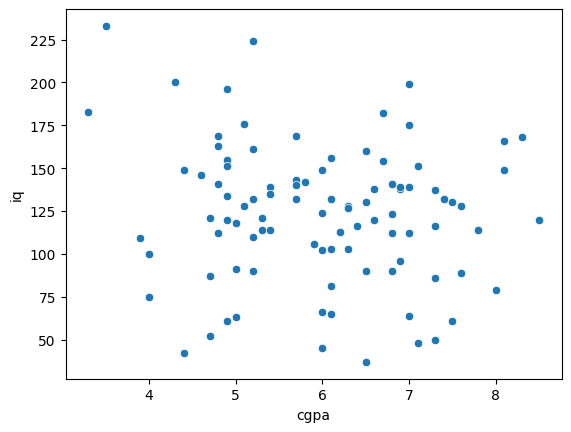

          cgpa        iq
cgpa  1.000000 -0.128172
iq   -0.128172  1.000000


In [16]:
# relationship between cgpa and iq
sns.scatterplot(data = df, x = 'cgpa', y = 'iq')
plt.show( )
corelation = df[['cgpa', 'iq']].corr( )
print(corelation)


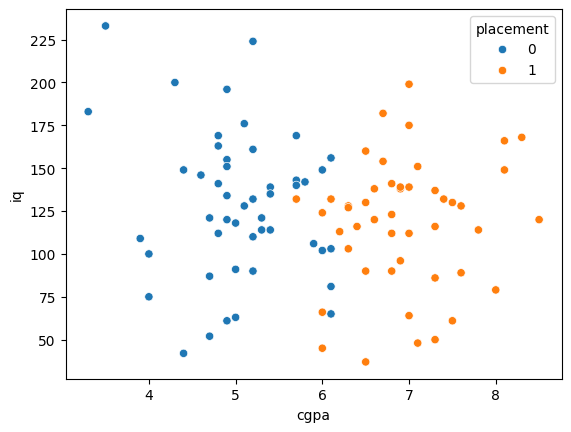

In [17]:
# relationship between cgpa, iq and placement
sns.scatterplot(data = df, x = 'cgpa', y = 'iq', hue = 'placement')
plt.show( )


In [26]:
mean_cgpa = df['cgpa'].mean( )
df.fillna({'cgpa': mean_cgpa}, inplace = True)
print(df.info( ))	# reports 100 cgpa values



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB
None


In [27]:
import numpy as np
print("Old df with outliers:")
print(df[df['iq'] > 200])
df['iq'] = np.where(df['iq'] > 200, 200, df['iq'])
print("New df with no outliers:")
print(df[df['iq'] > 200])


Old df with outliers:
    cgpa     iq placement
16   5.2  224.0        No
50   3.5  233.0        No
New df with no outliers:
Empty DataFrame
Columns: [cgpa, iq, placement]
Index: []


In [29]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler( )
df[['cgpa', 'iq']] = ss.fit_transform(df[['cgpa', 'iq']])
print(df.head( ))


       cgpa        iq placement
0  0.723422 -0.000260       Yes
1 -0.078816 -0.442829        No
2 -0.613642 -0.052327        No
3  1.258247  0.234041       Yes
4 -0.167954  0.494375        No


In [48]:
# features: CGPA and IQ
X = df[['cgpa', 'iq']]
# target Variable: Placement Status
y = df['placement']


In [49]:
from sklearn.model_selection import train_test_split
# split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)


In [50]:
from sklearn.linear_model import LogisticRegression
# create an instance of the Logistic Regression model
model = LogisticRegression( )
# training the model on the training data
model.fit(X_train, y_train)


LogisticRegression()

In [51]:
# make predictions on the test set
y_pred = model.predict(X_test)


In [52]:
from sklearn.metrics import accuracy_score
# calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 85.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


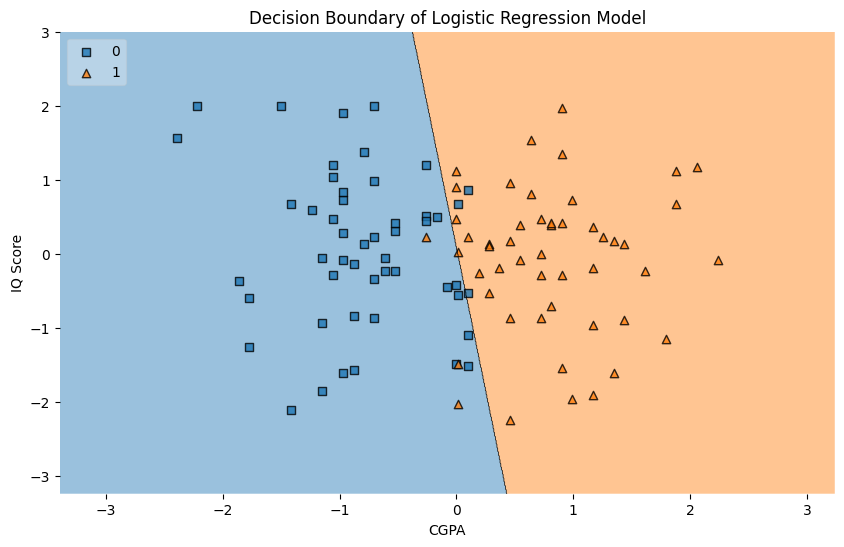

In [47]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

# combine training and test data for plotting
X_combined = pd.concat([X_train, X_test])
y_combined = pd.concat([y_train, y_test])

# plot the decision boundary
plt.figure(figsize = (10, 6))
plot_decision_regions(X_combined.values, y_combined.values, clf = model, legend = 2)

# adding axis labels and title
plt.xlabel('CGPA')
plt.ylabel('IQ Score')
plt.title('Decision Boundary of Logistic Regression Model')
plt.show( )


To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut 'Command/Ctrl+Enter'. To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine <strong>executable code</strong> and <strong>rich text</strong> in a single document, along with <strong>images</strong>, <strong>HTML</strong>, <strong>LaTeX</strong> and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To find out more, see <a href="/notebooks/basic_features_overview.ipynb">Overview of Colab</a>. To create a new Colab notebook you can use the File menu above, or use the following link: <a href="http://colab.research.google.com#create=true">Create a new Colab notebook</a>.

Colab notebooks are Jupyter notebooks that are hosted by Colab. To find out more about the Jupyter project, see <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyse and visualise data. The code cell below uses <strong>numpy</strong> to generate some random data, and uses <strong>matplotlib</strong> to visualise it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from GitHub and many other sources. To find out more about importing data, and how Colab can be used for data science, see the links below under <a href="#working-with-data">Working with data</a>.

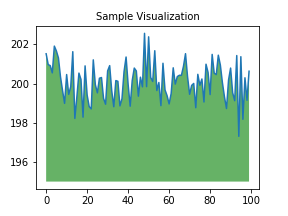

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning that you can leverage the power of Google hardware, including <a href="#using-accelerated-hardware">GPUs and TPUs</a>, regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for <strong>pandas</strong> code to finish running and want to go faster, you can switch to a GPU runtime and use libraries like <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a> that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">10-minute guide</a> or
 <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">US stock market data analysis demo</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it and evaluate the model, all in just <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">a few lines of code</a>.

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the <a href="#machine-learning-examples">machine learning examples</a> below.

<div class="markdown-google-sans">

## More resources

### Working with notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with data
</div>

- [Loading data: Drive, Sheets and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualising data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine learning

<div>

These are a few of the notebooks related to machine learning, including Google's online machine learning course. See the <a href="https://developers.google.com/machine-learning/crash-course/">full course website</a> for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using accelerated hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer &#40;ViT&#41; for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Train a miniGPT language model with JAX AI stack</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">LoRA/QLoRA finetuning for LLM using Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Loading Hugging Face transformers checkpoints</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">8-bit integer quantisation in Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Float8 training and inference with a simple transformer model</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Pretraining a transformer from scratch with KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Simple MNIST convnet</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Image classification from scratch using Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Image classification with KerasHub</a>
